# Laboratorio 1: Regresión en California

En este laboratorio deben hacer experimentos de regresión con el conjunto de datos "California Housing dataset".

Estudiarán el dataset, harán visualizaciones y seleccionarán atributos relevantes a mano.

Luego, entrenarán y evaluarán diferentes tipos de regresiones, buscando las configuraciones que mejores resultados den.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Carga del Conjunto de Datos

Cargamos el conjunto de datos y vemos su contenido.

In [2]:
from sklearn.datasets import fetch_california_housing
X_california, y_california = fetch_california_housing(return_X_y=True, as_frame=True)
california = fetch_california_housing()

In [3]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
print(california['DESCR'])  # descripción del dataset
#california['feature_names'] # nombres de los atributos para cada columna de 'data'
#california['data']           # matriz con los datos de entrada (atributos)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
print(california['target']) # vector de valores a predecir
print(california['target_names']) # nombres de los valores a predecir

[4.526 3.585 3.521 ... 0.923 0.847 0.894]
['MedHouseVal']


In [6]:
california['data'].shape, california['target'].shape

((20640, 8), (20640,))

In [8]:
# Dataframe con la mediana de valores de las propiedades
california_price = pd.DataFrame(california['target'], columns=['price_USD'])
#california_price*100000

In [9]:
#lista de columnas y sus caracteristicas
california_df = pd.DataFrame(california['data'], columns=california['feature_names']) #,
california_df.info()
california_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [12]:
# Concatenacion todo en un dataframe unico
california_df_total = pd.concat([california_df, california_price], axis=1)
california_df_total.info()
california_df_total.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price_USD   20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price_USD
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# Analisis para determinacion de valores null, None o ceros en las columnas del dataframe.

<Axes: >

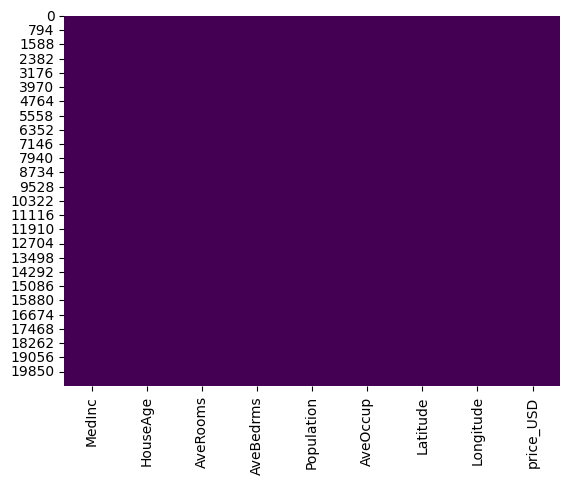

In [13]:
california_df_total[california_df_total==0].count(axis=0)
sns.heatmap(california_df_total==0, cbar=False, cmap='viridis')

<Axes: >

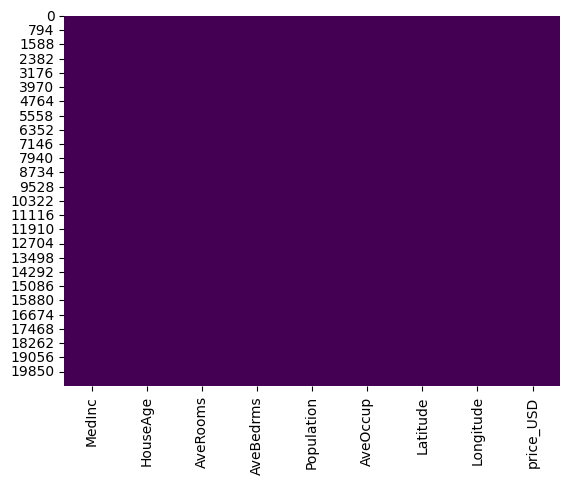

In [14]:
california_df_total[california_df_total.isnull()].count(axis=0)
sns.heatmap(california_df_total.isnull(), cbar=False, cmap='viridis')

<Axes: >

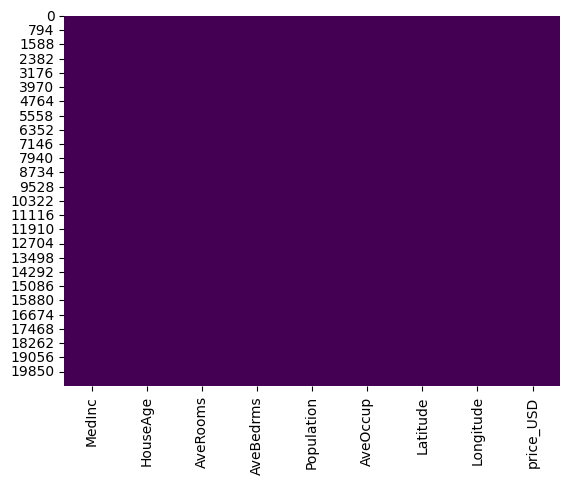

In [15]:
california_df_total[california_df_total==None].count(axis=0)
sns.heatmap(california_df_total==None, cbar=False, cmap='viridis')

# Distribucion y selecion de datos para la variable 'MedInc'

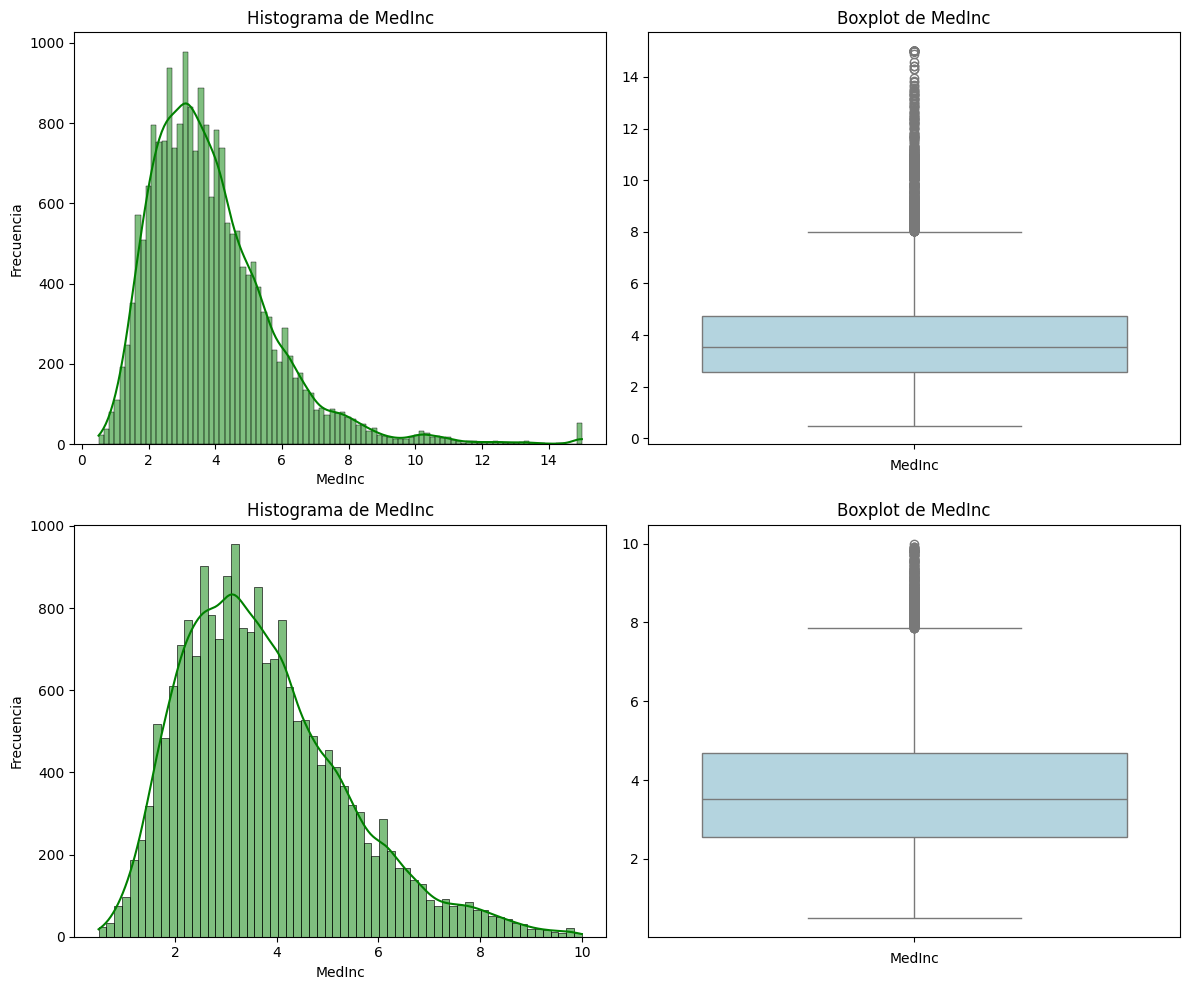

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
sns.histplot(california_df_total['MedInc'], ax=axes[0, 0], kde=True,color='green')
axes[0, 0].set_title('Histograma de MedInc')
axes[0, 0].set_xlabel('MedInc')
axes[0, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total['MedInc'], ax=axes[0, 1], color='lightblue')
axes[0, 1].set_title('Boxplot de MedInc')
axes[0, 1].set_xlabel('MedInc')
axes[0, 1].set_ylabel('')
sns.histplot(california_df_total[california_df_total['MedInc']<=10]['MedInc'], ax=axes[1, 0], kde=True,color='green')
axes[1, 0].set_title('Histograma de MedInc')
axes[1, 0].set_xlabel('MedInc')
axes[1, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total[california_df_total['MedInc']<=10]['MedInc'], ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Boxplot de MedInc')
axes[1, 1].set_xlabel('MedInc')
axes[1, 1].set_ylabel('')
plt.tight_layout()
plt.show()

# Podemos recortar los datos para cuando 'MedInc' es menor o igual a 10, porque la mayor distribución de datos estan dados para valores menores a 10.

# Distribucion y selecion de datos para la variable 'HouseAge'

Text(0, 0.5, '')

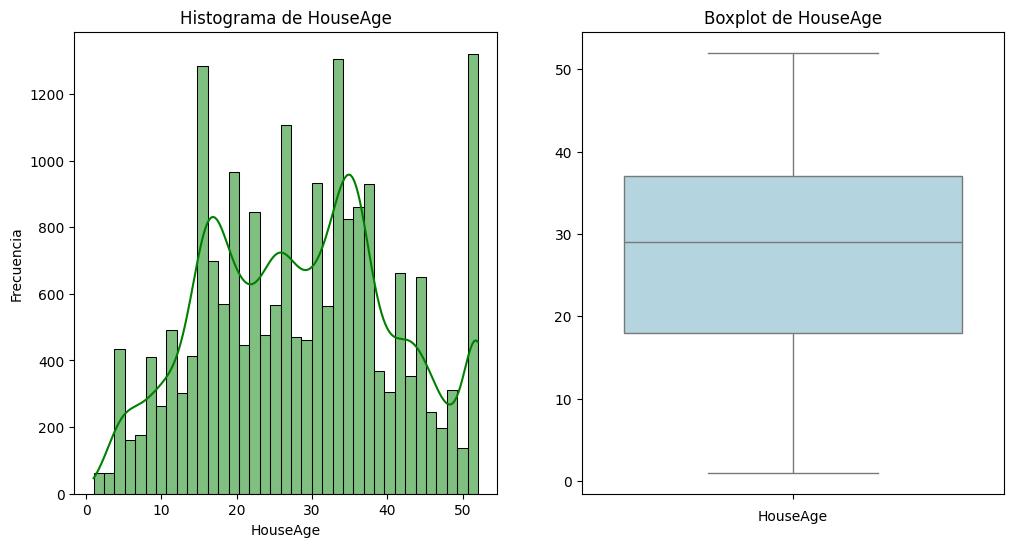

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.histplot(california_df_total['HouseAge'], ax=axes[0], kde=True,color='green')
axes[0].set_title('Histograma de HouseAge')
axes[0].set_xlabel('HouseAge')
axes[0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total['HouseAge'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot de HouseAge')
axes[1].set_xlabel('HouseAge')
axes[1].set_ylabel('')

# Distribucion y selecion de datos para la variable 'AveRooms'

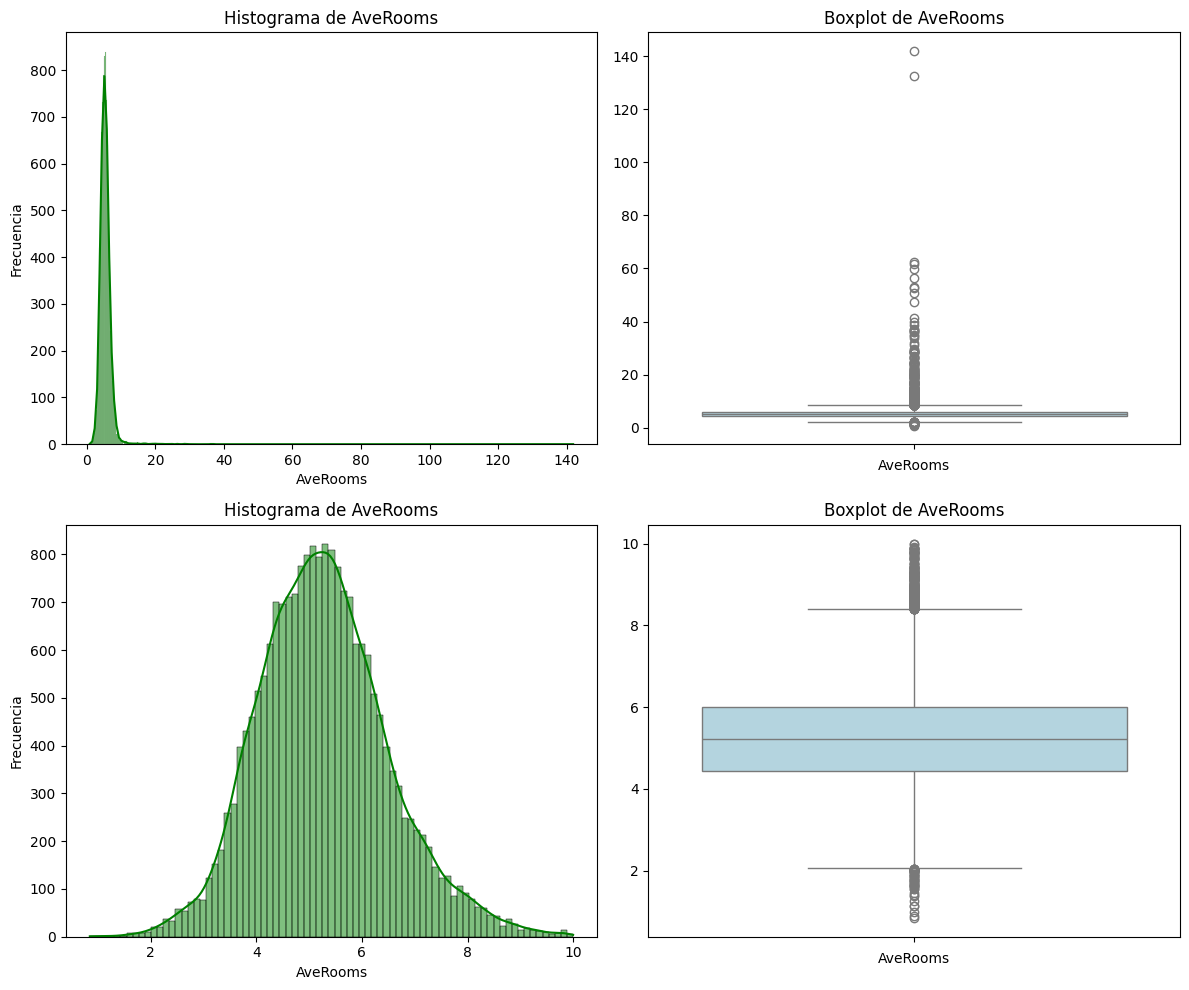

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
sns.histplot(california_df_total['AveRooms'], ax=axes[0, 0], kde=True,color='green')
axes[0, 0].set_title('Histograma de AveRooms')
axes[0, 0].set_xlabel('AveRooms')
axes[0, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total['AveRooms'], ax=axes[0, 1], color='lightblue')
axes[0, 1].set_title('Boxplot de AveRooms')
axes[0, 1].set_xlabel('AveRooms')
axes[0, 1].set_ylabel('')
sns.histplot(california_df_total[california_df_total['AveRooms']<=10]['AveRooms'], ax=axes[1, 0], kde=True,color='green')
axes[1, 0].set_title('Histograma de AveRooms')
axes[1, 0].set_xlabel('AveRooms')
axes[1, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total[california_df_total['AveRooms']<=10]['AveRooms'], ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Boxplot de AveRooms')
axes[1, 1].set_xlabel('AveRooms')
axes[1, 1].set_ylabel('')
plt.tight_layout()
plt.show()

# Podemos recortar los datos utilizando valor para la variable 'AveRooms' menor o igual a 10.

# Distribucion de datos para la variable 'AveBedrms'

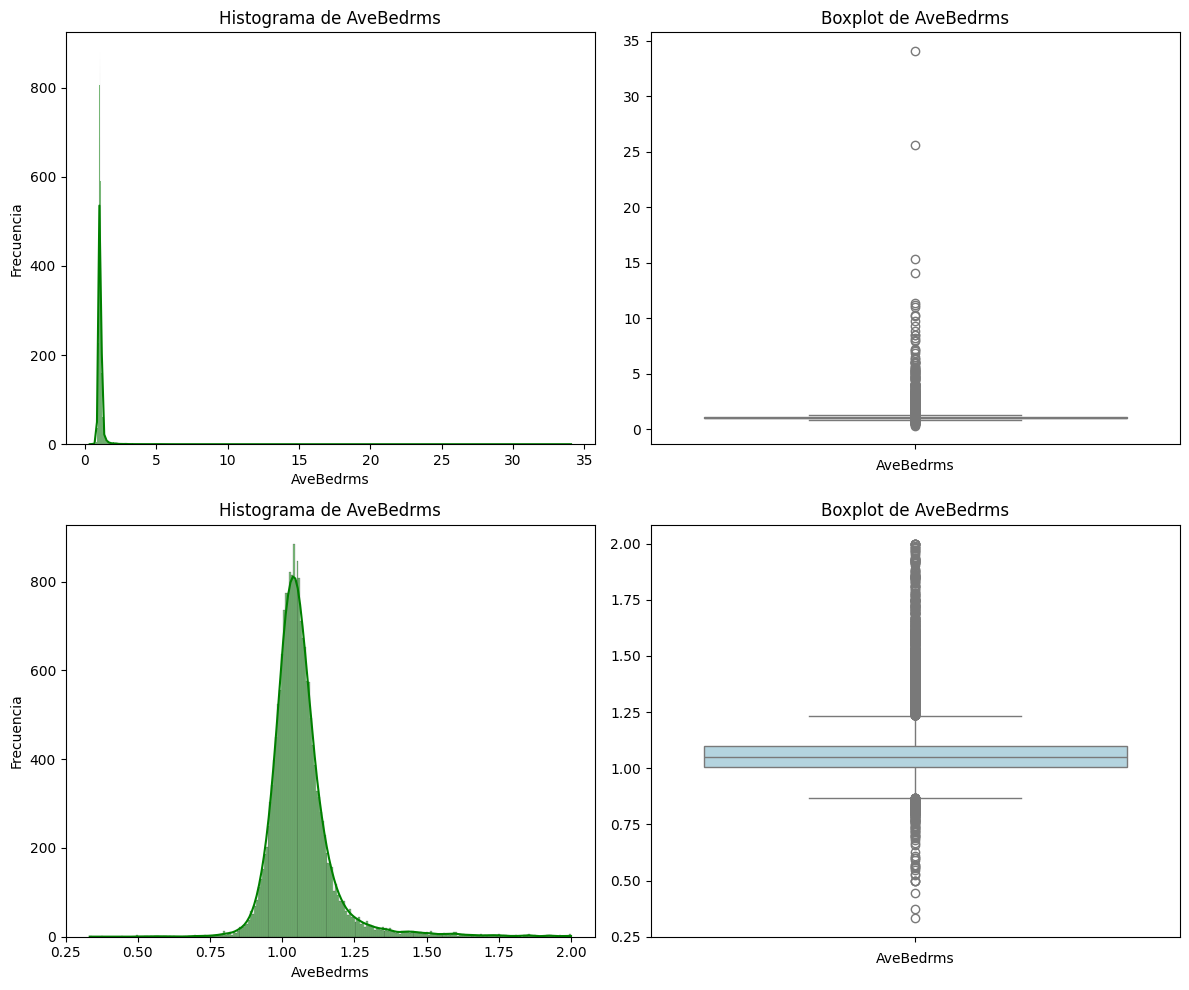

In [19]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
sns.histplot(california_df_total['AveBedrms'], ax=axes[0, 0], kde=True,color='green')
axes[0, 0].set_title('Histograma de AveBedrms')
axes[0, 0].set_xlabel('AveBedrms')
axes[0, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total['AveBedrms'], ax=axes[0, 1], color='lightblue')
axes[0, 1].set_title('Boxplot de AveBedrms')
axes[0, 1].set_xlabel('AveBedrms')
axes[0, 1].set_ylabel('')
sns.histplot(california_df_total[california_df_total['AveBedrms']<=2]['AveBedrms'], ax=axes[1, 0], kde=True,color='green')
axes[1, 0].set_title('Histograma de AveBedrms')
axes[1, 0].set_xlabel('AveBedrms')
axes[1, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total[california_df_total['AveBedrms']<=2]['AveBedrms'], ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Boxplot de AveBedrms')
axes[1, 1].set_xlabel('AveBedrms')
axes[1, 1].set_ylabel('')
plt.tight_layout()
plt.show()

# Podemos recortar los datos para cuando 'AveBedrms' es menor o igual a 2.

# Distribucion de datos para la variable 'Population'

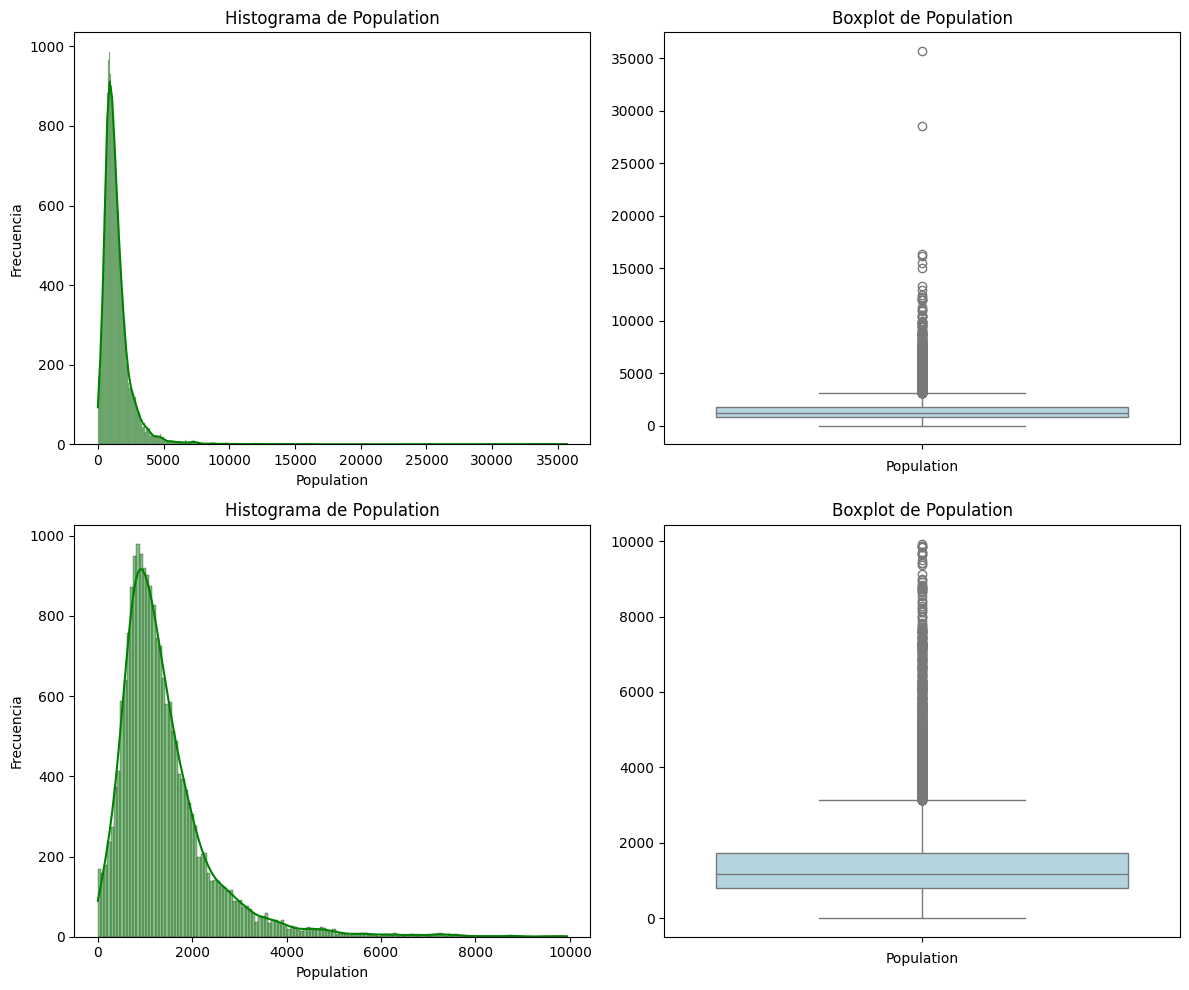

In [20]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
sns.histplot(california_df_total['Population'], ax=axes[0, 0], kde=True,color='green')
axes[0, 0].set_title('Histograma de Population')
axes[0, 0].set_xlabel('Population')
axes[0, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total['Population'], ax=axes[0, 1], color='lightblue')
axes[0, 1].set_title('Boxplot de Population')
axes[0, 1].set_xlabel('Population')
axes[0, 1].set_ylabel('')
sns.histplot(california_df_total[california_df_total['Population']<=10000]['Population'], ax=axes[1, 0], kde=True,color='green')
axes[1, 0].set_title('Histograma de Population')
axes[1, 0].set_xlabel('Population')
axes[1, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total[california_df_total['Population']<=10000]['Population'], ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Boxplot de Population')
axes[1, 1].set_xlabel('Population')
axes[1, 1].set_ylabel('')
plt.tight_layout()
plt.show()

# Podemos recortar los datos para cuando 'Population' es menor o igual a 10000.

# Distribucion de datos para la variable 'AveOccup'

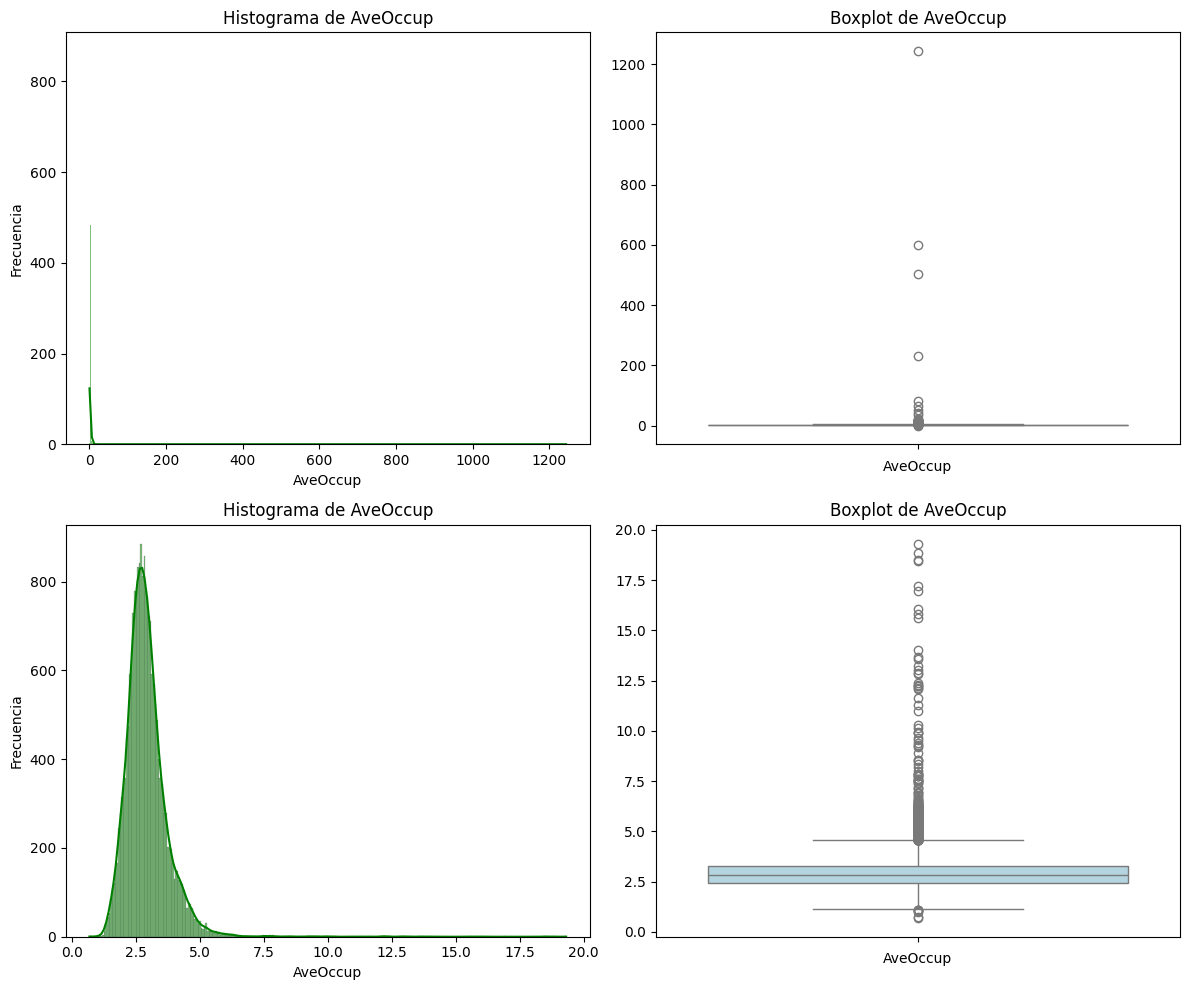

In [21]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
sns.histplot(california_df_total['AveOccup'], ax=axes[0, 0], kde=True,color='green')
axes[0, 0].set_title('Histograma de AveOccup')
axes[0, 0].set_xlabel('AveOccup')
axes[0, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total['AveOccup'], ax=axes[0, 1], color='lightblue')
axes[0, 1].set_title('Boxplot de AveOccup')
axes[0, 1].set_xlabel('AveOccup')
axes[0, 1].set_ylabel('')
sns.histplot(california_df_total[california_df_total['AveOccup']<=20]['AveOccup'], ax=axes[1, 0], kde=True,color='green')
axes[1, 0].set_title('Histograma de AveOccup')
axes[1, 0].set_xlabel('AveOccup')
axes[1, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total[california_df_total['AveOccup']<=20]['AveOccup'], ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Boxplot de AveOccup')
axes[1, 1].set_xlabel('AveOccup')
axes[1, 1].set_ylabel('')
plt.tight_layout()
plt.show()

# Podemos recortar los datos para cuando 'AveOccup' es menor o igual a 20.

# Distribucion de datos para la variable 'price_USD'

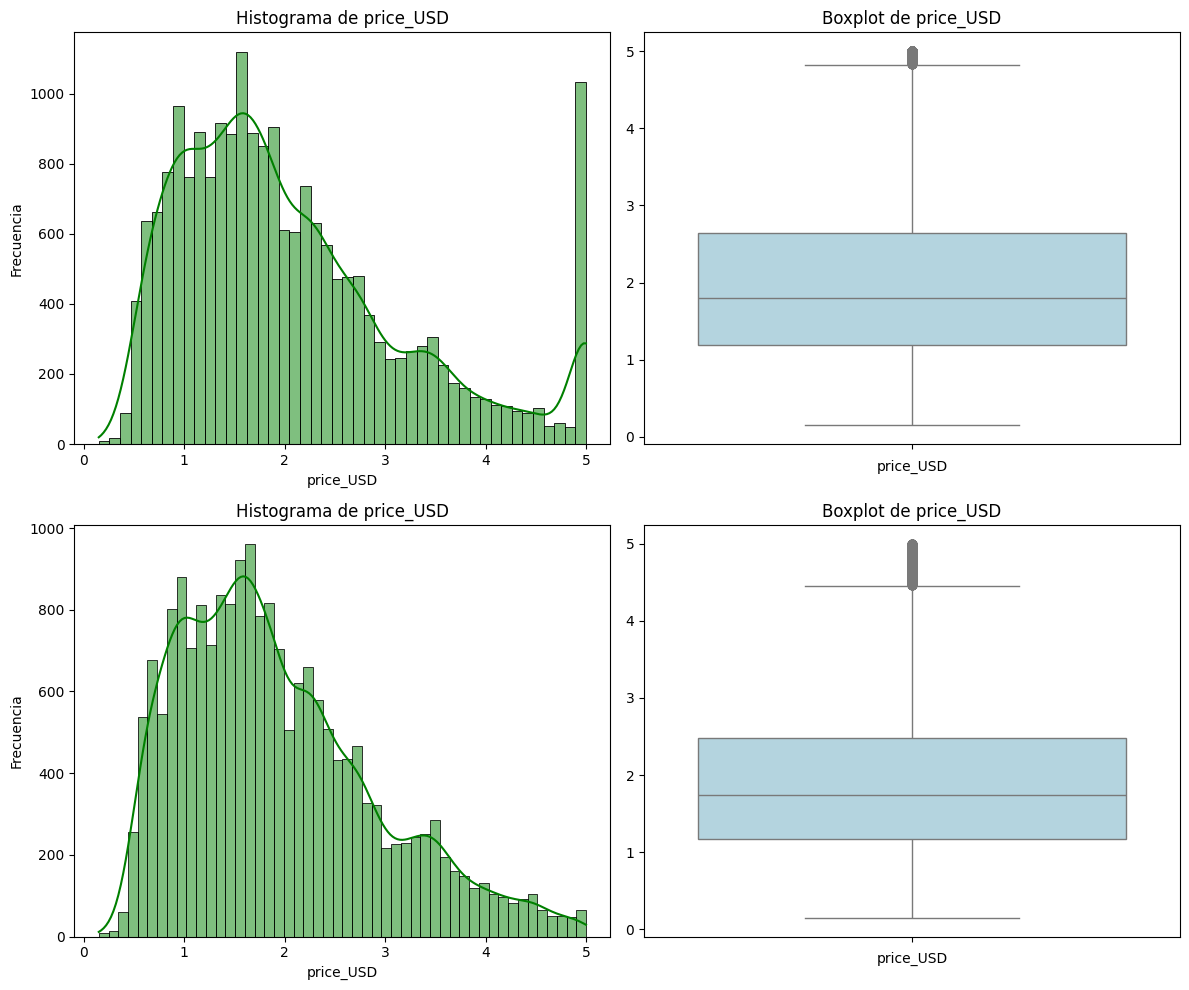

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
sns.histplot(california_df_total['price_USD'], ax=axes[0, 0], kde=True,color='green')
axes[0, 0].set_title('Histograma de price_USD')
axes[0, 0].set_xlabel('price_USD')
axes[0, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total['price_USD'], ax=axes[0, 1], color='lightblue')
axes[0, 1].set_title('Boxplot de price_USD')
axes[0, 1].set_xlabel('price_USD')
axes[0, 1].set_ylabel('')
sns.histplot(california_df_total[california_df_total['price_USD']<=5]['price_USD'], ax=axes[1, 0], kde=True,color='green')
axes[1, 0].set_title('Histograma de price_USD')
axes[1, 0].set_xlabel('price_USD')
axes[1, 0].set_ylabel('Frecuencia')
sns.boxplot(california_df_total[california_df_total['price_USD']<=5]['price_USD'], ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Boxplot de price_USD')
axes[1, 1].set_xlabel('price_USD')
axes[1, 1].set_ylabel('')
plt.tight_layout()
plt.show()

# Podriamos considerar los valores de las casas mayores a 5 como outliers de la distribucion, considerando el boxplot de la muestra. Pero teniendo en cuenta que  representa un valor significativo, inicialmente vamos a considerarlo para nuestra prediccion y luego analizaremos si podemos descartarlo.

# Seleccion de la muestra a ser predicta

'MedInc'<=10,
'AveRooms'<=10,
'AveBedrms'<=2,
'Population'<=10000,
'AveOccup'<=20. Optional:
'price_USD'<=5

## Ejercicio 1: Descripción de los Datos y la Tarea

Responda las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponibles para hacer la predicción?
4. ¿Qué atributos imagina ud. que serán los más determinantes para la predicción?
5. ¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras.

**No hace falta escribir código para responder estas preguntas.**

# Respuestas

1. El conjunto de datos corresponde al **California Housing dataset**. Se trata de un conjunto de datos que contiene información sobre características de un grupo de viviendas, a nivel de "block group" en California. Un "block group" es la unidad geográfica más pequeña para la que la Oficina del Censo de EE.UU. publica datos de muestra (suele tener una población de 600 a 3.000 personas).

2. La variable objetivo que hay que predecir es el valor de la mediana de las casas para cada "block group" en los distritos de California, expresado en cientos de miles de dólares ($100.000). La librería scikit-learn nos proporciona la variable objetivo (columna *target*) al cargar el **California Housing dataset**.

3. Los atributos disponibles para cada "block group" son:

*   MedInc (median income in block group):
mediana del ingreso de las personas que viven en ese grupo de viviendas.

*   HouseAge (median house age in block group): mediana de la edad de las casas en ese grupo.

*   AveRooms (average number of rooms per household): número promedio de habitaciones por hogar en el grupo.

*   AveBedrms (average number of bedrooms per household): número promedio de dormitorios por hogar.

*   Population (block group population): población total del grupo de viviendas.

*   AveOccup (average number of household members): número promedio de personas que viven en cada hogar dentro del grupo.

*   Latitude (block group latitude): latitud de la ubicación geográfica del grupo de viviendas.

*   Longitude (block group longitude): longitud de la ubicación geográfica del grupo de viviendas. Junto con la latitud, define la ubicación precisa del grupo.

4. Teniendo en cuenta trabajos anteriores, los atributos principales para predecir el valor de las viviendas podrían ser:

*   MedInc: Un ingreso medio más alto podría estar relacionado con casas más caras.

*   AveRooms: Más habitaciones por hogar podrían indicar casas más grandes.

*   Latitude y Longitude: La ubicación es un factor ihoy mportante en el valor de una propiedad.

5. Posibles sesgos, riesgos, dilemas éticos, etc:

*   Sesgo geográfico: Los datos se centran en California. Esto significa que cualquier modelo entrenado con este conjunto de datos podría no generalizar bien a otras regiones de USA o del mundo.

*   Agrupamiento por "block group": no tenemos información detallada sobre las viviendas individuales dentro de cada grupo, las predicciones que se hagan se basan en promedios. Si dentro de un "block group" hay una gran disparidad de precios de viviendas, el promedio podría no ser una representación precisa del valor de la mayoría de las casas en ese grupo.



## Ejercicio 2: Visualización de los Datos

1. Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.
2. Estudie las gráficas, identificando **a ojo** los atributos que a su criterio sean los más informativos para la predicción.
3. Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.

# Respuesta Ejercicio 2

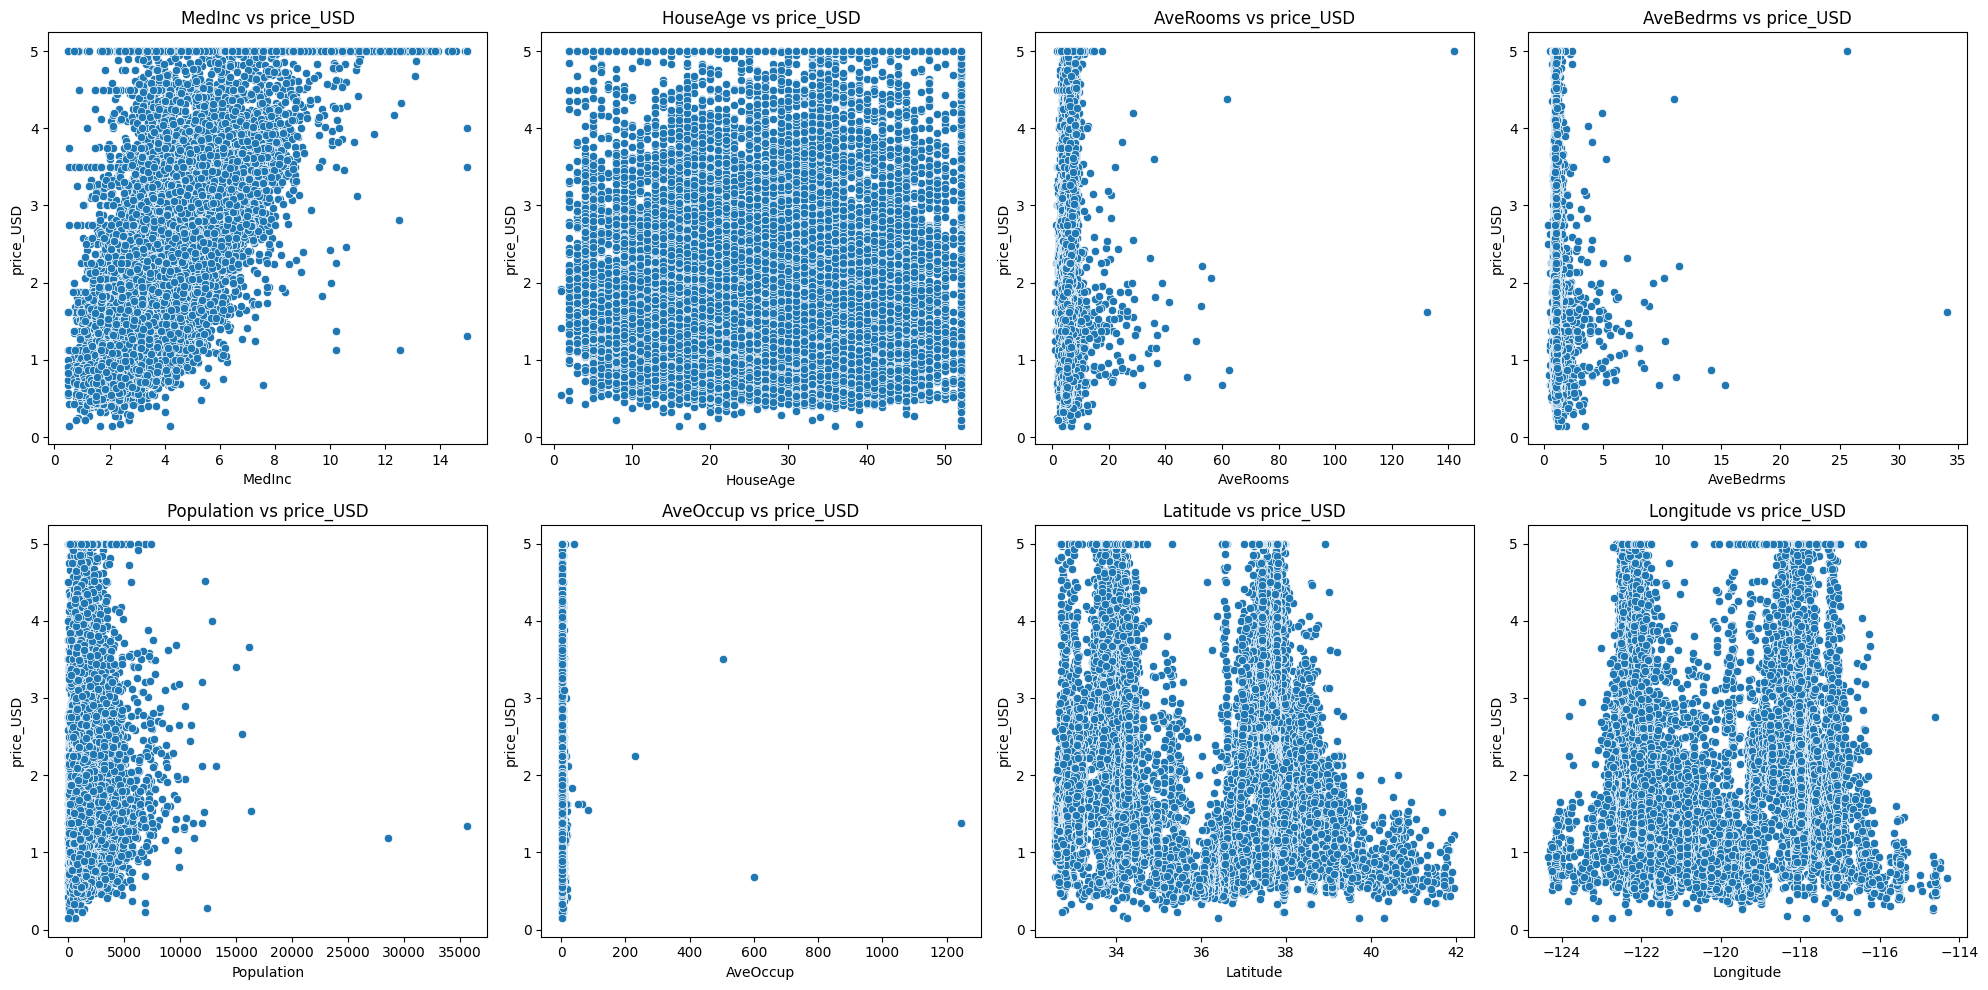

In [23]:
# Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

for i, col in enumerate(features):
  sns.scatterplot(data=california_df_total, x=col, y='price_USD', ax=axes[i])
  axes[i].set_title(f'{col} vs price_USD')

plt.tight_layout()
plt.show()

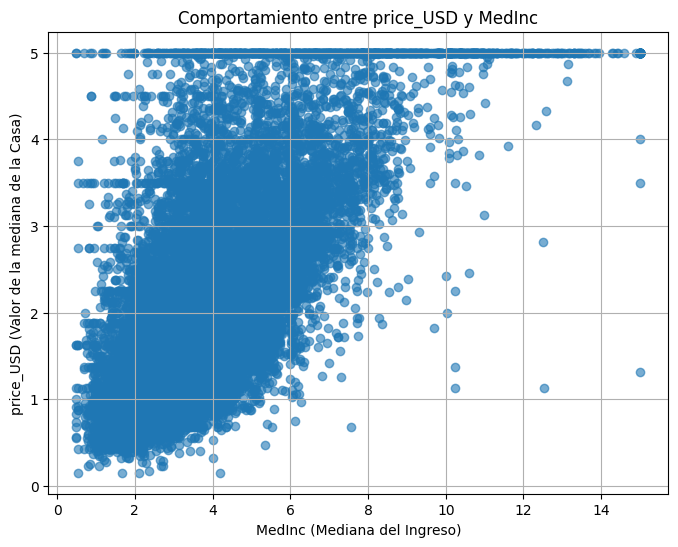

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(california_df_total['MedInc'],california_df_total['price_USD'], alpha=0.6)
plt.title('Comportamiento entre price_USD y MedInc')
plt.xlabel('MedInc (Mediana del Ingreso)')
plt.ylabel('price_USD (Valor de la mediana de la Casa)')
plt.grid(True)
plt.show()

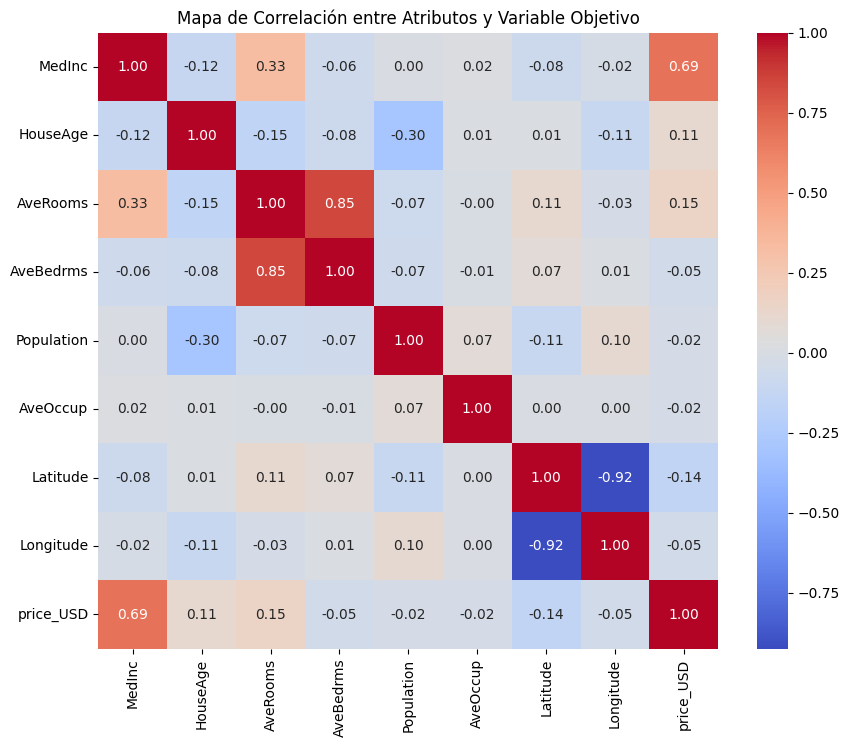

In [25]:
# mapa de correlacion entre los atributos y la variable objetivo

import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(california_df_total.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación entre Atributos y Variable Objetivo')
plt.show()

In [31]:
# 3. Listado de atributos en orden de importancia.
california_df_with_target = california_df_total.copy()
correlation_with_target = california_df_with_target.corr()['price_USD'].sort_values(ascending=False)
print("Coeficientes de correlación con la variable objetivo:")
print(correlation_with_target)

Coeficientes de correlación con la variable objetivo:
price_USD     1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: price_USD, dtype: float64


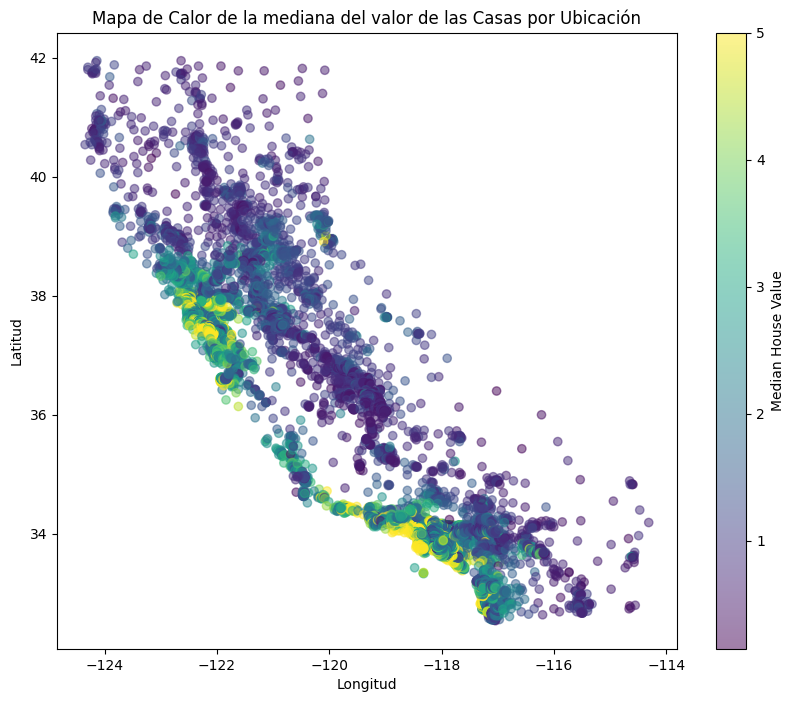

In [26]:
# Mapa de calor de la ubicación respecto a la variable objetivo
plt.figure(figsize=(10, 8))
plt.scatter(california_df_total['Longitude'], california_df_total['Latitude'], c=california_df_total['price_USD'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Median House Value')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Mapa de Calor de la mediana del valor de las Casas por Ubicación')
plt.show()

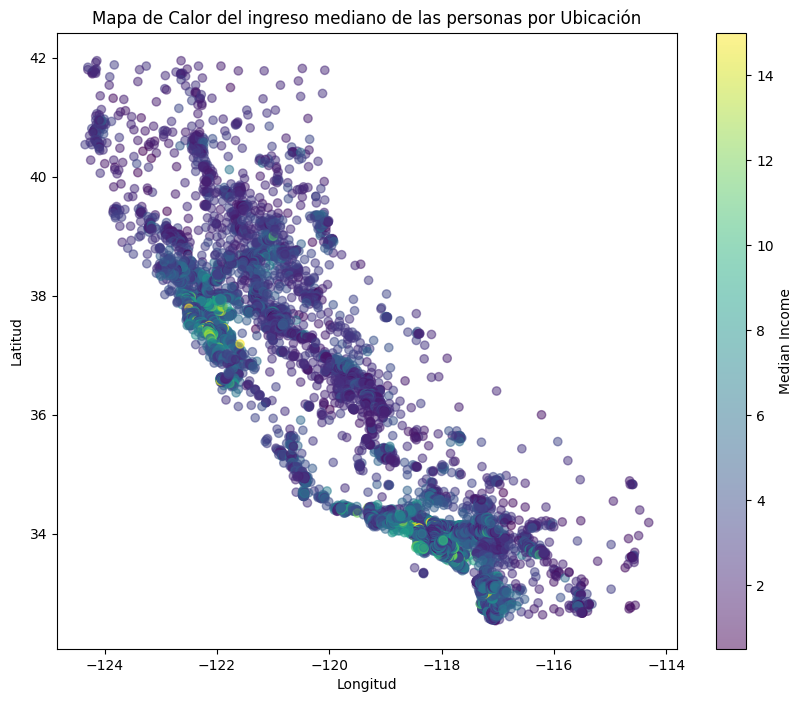

In [28]:
# Mapa de calor de la ubicación respecto a la variable MedInc
plt.figure(figsize=(10, 8))
plt.scatter(california_df_total['Longitude'], california_df_total['Latitude'], c=california_df_total['MedInc'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Median Income')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Mapa de Calor del ingreso mediano de las personas por Ubicación')
plt.show()

2. Estudie las gráficas, identificando **a ojo** los atributos que a su criterio sean los más informativos para la predicción.

Analizando las graficas variable vs. price_USD y mapa de correlación, podemos ver que los atributos que correlacionan mejor con la variable objetivo son: MedInc, HouseAge y AveRooms. La variable ubicación (Latitud y Longitud), si bien no presenta buena correlación, en la graficas mapas de calor se puede ver que hay una ubicación preferencial para las viviendas más costosas.

## Ejercicio 3: Regresión Lineal

1. Seleccione **un solo atributo** que considere puede ser el más apropiado.
2. Instancie una regresión lineal de **scikit-learn**, y entrénela usando sólo el atributo seleccionado.
3. Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.
4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se puede obtener un error en test menor a 50.

In [34]:
# Seleccion de la muestra a ser predicta
california_df_pred = california_df_total[(california_df_total['MedInc']<=10)&(california_df_total['AveRooms']<=10)&(california_df_total['AveBedrms']<=2)&(california_df_total['Population']<=10000)&(california_df_total['AveOccup']<=20)]
california_df_pred1 = california_df_total[(california_df_total['MedInc']<=10)&(california_df_total['AveRooms']<=10)&(california_df_total['AveBedrms']<=2)&(california_df_total['Population']<=10000)&(california_df_total['AveOccup']<=20)&(california_df_total['price_USD']<=5)]
california_df_pred.describe()
california_df_pred1.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price_USD
count,19342.000000,19342.000000,19342.000000,19342.000000,19342.000000,19342.000000,19342.000000,19342.000000,19342.000000
mean,3.659256,28.559456,5.195407,1.063193,1436.380312,2.956223,35.638458,-119.571211,1.924648
std,1.526881,12.465248,1.152276,0.111953,1037.300035,0.855175,2.142060,2.002911,0.972585
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.750000,32.540000,-124.350000,0.149990
25%,2.523800,18.000000,4.401372,1.005270,806.000000,2.450131,33.930000,-121.780000,1.167000
50%,3.445150,29.000000,5.161639,1.047497,1186.000000,2.842219,34.260000,-118.495000,1.741000
75%,4.574200,37.000000,5.933743,1.096491,1752.000000,3.309512,37.720000,-118.000000,2.484000
max,9.905500,52.000000,10.000000,2.000000,9936.000000,19.312500,41.950000,-114.550000,5.000000


# Respuesta Ejercicio 3

1. Teniendo en cuenta lo visto en el ejercicio 2, elegimos el atributo '**MedInc**' ya que es el que tiene mayor correlación con la variable objetivo.

In [35]:
from sklearn.model_selection import train_test_split
y = california_df_pred['price_USD']
X = california_df_pred['MedInc']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)
X_train.shape, X_test.shape

((16031,), (4008,))

In [36]:
# Definir las colunas como arrays
X_train= X_train.to_numpy().reshape(-1, 1)
X_test = X_test.to_numpy().reshape(-1, 1)
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

train_errors = []
val_errors = []
degrees = [1]
for degree in degrees:
    # train:
    pf = PolynomialFeatures(degree)
    lr = LinearRegression(fit_intercept=False)
    model = make_pipeline(pf, lr)

    X_train = X_train.reshape(-1, 1)
    y_train = y_train.reshape(-1, 1)
    model.fit(X_train, y_train)

    # predict:
    y_train_pred = model.predict(X_train)
    X_test = X_test.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)
    y_val_pred = model.predict(X_test)

    # evaluate:
    train_error = mean_squared_error(y_train, y_train_pred)
    val_error = mean_squared_error(y_test, y_val_pred)
    train_errors.append(train_error)
    val_errors.append(val_error)

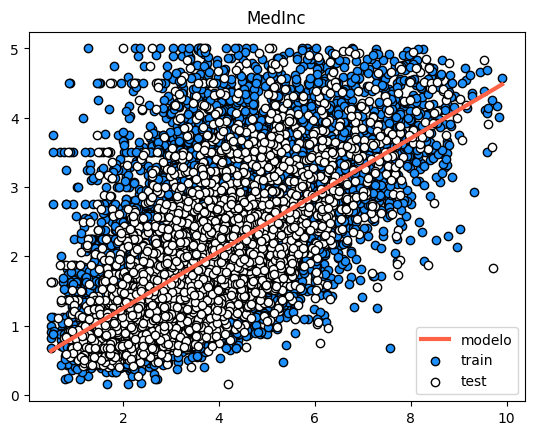

In [44]:
# 3 Grafica del ajuste de la regresion lineal
x_start = min(np.min(X_train), np.min(X_test))
x_end = max(np.max(X_train), np.max(X_test))
x = np.linspace(x_start, x_end, 200).reshape(-1, 1)

plt.plot(x, model.predict(x), color="tomato", label="modelo", linewidth=3)
plt.scatter(X_train, y_train, facecolor="dodgerblue", edgecolor="k", label="train")
plt.scatter(X_test, y_test, facecolor="white", edgecolor="k", label="test")
plt.title('MedInc')
plt.legend()
plt.show()

In [41]:
# 3. Calculamos el Error Cuadrático Medio
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_val_pred)
print(f'Error Cuadrático Medio (entrenamiento): {mse_train}')
print(f'Error Cuadrático Medio (evaluación): {mse_test}')

Error Cuadrático Medio (entrenamiento): 0.6917823042588531
Error Cuadrático Medio (evaluación): 0.6880915392028208


# Ahora hacemos el mismo analisis para la muestra MedInc <= 10, para ver si el ajuste mejora.

In [42]:
y_filter = california_df_pred1['price_USD']
X_filter = california_df_pred1['MedInc']

X_train, X_test, y_train, y_test = train_test_split(X_filter, y_filter, train_size=0.8, random_state=0)

X_train= X_train.to_numpy().reshape(-1, 1)
X_test = X_test.to_numpy().reshape(-1, 1)
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

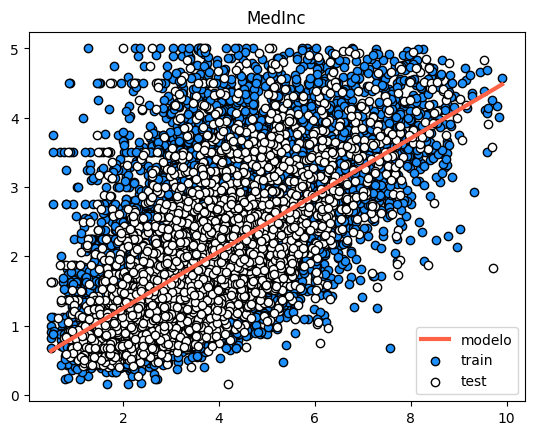

In [45]:
train_errors = []
val_errors = []
degrees = [1]
for degree in degrees:
    # train:
    pf = PolynomialFeatures(degree)
    lr = LinearRegression(fit_intercept=False)
    model = make_pipeline(pf, lr)

    X_train = X_train.reshape(-1, 1)
    y_train = y_train.reshape(-1, 1)
    model.fit(X_train, y_train)

    # predict:
    y_train_pred = model.predict(X_train)
    X_test = X_test.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)
    y_val_pred = model.predict(X_test)

    # evaluate:
    train_error = mean_squared_error(y_train, y_train_pred)
    val_error = mean_squared_error(y_test, y_val_pred)
    train_errors.append(train_error)
    val_errors.append(val_error)


# 4. Grafica
x_start = min(np.min(X_train), np.min(X_test))
x_end = max(np.max(X_train), np.max(X_test))
x = np.linspace(x_start, x_end, 200).reshape(-1, 1)

plt.plot(x, model.predict(x), color="tomato", label="modelo", linewidth=3)
plt.scatter(X_train, y_train, facecolor="dodgerblue", edgecolor="k", label="train")
plt.scatter(X_test, y_test, facecolor="white", edgecolor="k", label="test")
plt.title('MedInc')
plt.legend()
plt.show()

In [46]:
# calcular error cuadratico medio
mse_train_filtered = mean_squared_error(y_train, y_train_pred)
mse_test_filtered = mean_squared_error(y_test, y_val_pred)

print(f'Error Cuadrático Medio (entrenamiento - MedInc <= 10 y price_USD < 5): {mse_train_filtered}')
print(f'Error Cuadrático Medio (evaluación - MedInc <= 10 y price_USD < 5): {mse_test_filtered}')


Error Cuadrático Medio (entrenamiento - MedInc <= 10 y price_USD < 5): 0.5564267287139814
Error Cuadrático Medio (evaluación - MedInc <= 10 y price_USD < 5): 0.5504232672217344


 5. Interpretamos el resultado

El modelo de regresión lineal entrenado con solo 'MedInc' muestra una tendencia positiva, lo que confirma la correlación lineal que observamos previamente.

El Error Cuadrático Medio en el conjunto de evaluación sin filtrar es de aproximadamente 0.69, lo cual es relativamente alto considerando que la variable objetivo está en unidades de 100,000 USD (lo que implica un error promedio de sqrt(0.69) * 100,000 USD = 83,000 USD). El Error Cuadrático Medio en el en el conjunto de evaluación filtrado, es de 0.53. Esto demuestra que el modelo lineal se ajusta mejor al subconjunto de datos "central", donde la relación lineal entre 'MedInc' y 'price_USD' es más pronunciada.


Esto sugiere que 'MedInc' por sí solo no es suficiente para predecir con precisión el valor de la vivienda. La gráfica muestra que el modelo captura la tendencia general, pero hay mucha dispersión en los datos que no puede ser explicada por una sola variable lineal.

Es crucial recordar que este modelo solo es aplicable y válido para predecir el valor de viviendas dentro de los rangos de 'MedInc' y 'price_USD' definidos por el filtro. No debería usarse para predecir valores fuera de este rango, ya que el comportamiento de la relación puede ser diferente en los valores atípicos.

## Ejercicio 4: Regresión Polinomial

En este ejercicio deben entrenar regresiones polinomiales de diferente complejidad, siempre usando **scikit-learn**.

Deben usar **el mismo atributo** seleccionado para el ejercicio anterior.

1. Para varios grados de polinomio, haga lo siguiente:
    1. Instancie y entrene una regresión polinomial.
    2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
    3. Guarde los errores en una lista.
2. Grafique las curvas de error en términos del grado del polinomio.
3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.
4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se pueden obtener errores en test menores a 40 e incluso a 35.

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Las variables entrenamieto y de teste son las mismas que usabamos para el mejor modelo
train_errors = []
val_errors = []
degrees = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14]
for degree in degrees:
    # train:
    pf = PolynomialFeatures(degree)
    lr = LinearRegression(fit_intercept=False)
    model = make_pipeline(pf, lr)
    X_train = X_train.reshape(-1, 1)
    y_train = y_train.reshape(-1, 1)
    model.fit(X_train, y_train)

    # predict:
    y_train_pred = model.predict(X_train)
    X_test = X_test.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)
    y_val_pred = model.predict(X_test)

    # evaluate:
    train_error = mean_squared_error(y_train, y_train_pred)
    val_error = mean_squared_error(y_test, y_val_pred)
    train_errors.append(train_error)
    val_errors.append(val_error)

In [48]:
#train_errors, val_errors

([0.9431890429476931,
  0.5564267287139814,
  0.5561939394652687,
  0.5557460585557114,
  0.5555791035269687,
  0.5537079761776608,
  0.5522996761707841,
  0.552298609269494,
  0.5522177389042667,
  0.5521753120880682,
  0.5521814371864532,
  0.552181568012273,
  0.6692144699399635],
 [0.9566579818299864,
  0.5504232672217344,
  0.5500128652432567,
  0.5495084547906647,
  0.5498462018154822,
  0.5474572379538114,
  0.5473259723014902,
  0.5473706371335865,
  0.5470903986301456,
  0.547211112437087,
  0.5471234684820847,
  0.5473713563736831,
  0.6729843809222062])

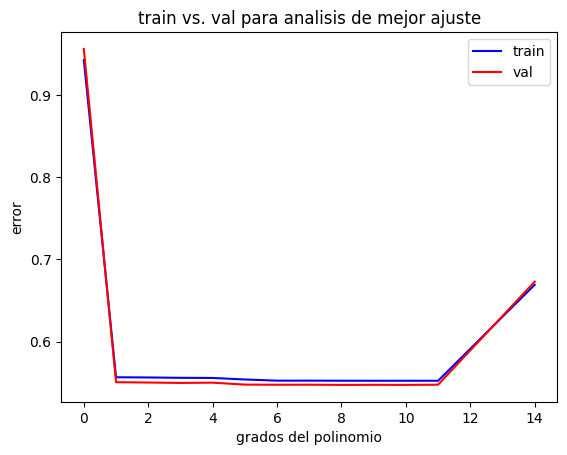

In [51]:
plt.plot(degrees, train_errors, color="blue", label="train")
plt.plot(degrees, val_errors, color="red", label="val")
plt.legend()
plt.xlabel("grados del polinomio")
plt.ylabel("error")
plt.title("train vs. val para analisis de mejor ajuste")
plt.show()

3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.

Observando los valores de errores para los diferentes grados, se puede ver que el test_error comienza a aumentar después de grado 10 aproximadamente. Esto indicaría que el modelo está empezando a sobreajustar los datos de entrenamiento.

El mejor grado de polinomio es: 8
Error Cuadrático Medio (entrenamiento - Mejor Modelo, grado 8): 0.5522177389042667
Error Cuadrático Medio (evaluación - Mejor Modelo, grado 8): 0.5470903986301456


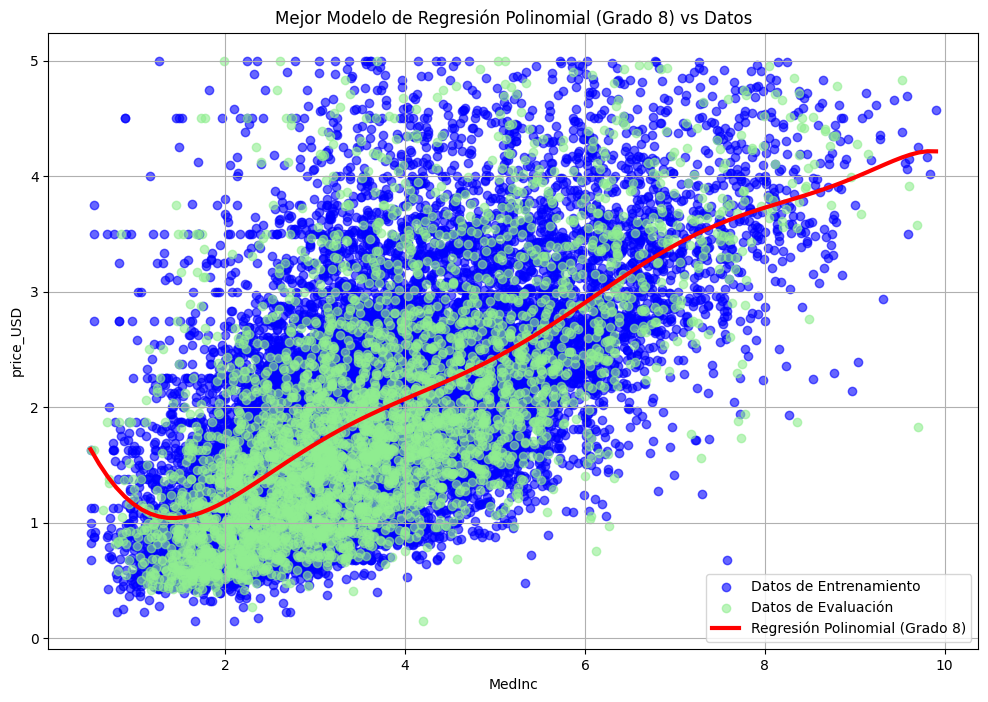

In [52]:
import matplotlib.pyplot as plt
import numpy as np
# Encuentra el grado con el menor error de validación
best_degree_index = np.argmin(val_errors)
best_degree = degrees[best_degree_index]
print(f"El mejor grado de polinomio es: {best_degree}")

# Entrena el modelo con el mejor grado de polinomio
pf = PolynomialFeatures(best_degree)
lr = LinearRegression(fit_intercept=False)
best_model = make_pipeline(pf, lr)

# Asegurarse de que los datos de entrenamiento y prueba tengan la forma correcta
X_train_reshaped = X_train.reshape(-1, 1)
y_train_reshaped = y_train.reshape(-1, 1)
X_test_reshaped = X_test.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

best_model.fit(X_train_reshaped, y_train_reshaped)

# Predecir sobre los conjuntos de entrenamiento y evaluación con el mejor modelo
y_train_pred_best = best_model.predict(X_train_reshaped)
y_test_pred_best = best_model.predict(X_test_reshaped)

# Calcular errores para el mejor modelo
mse_train_best = mean_squared_error(y_train_reshaped, y_train_pred_best)
mse_test_best = mean_squared_error(y_test_reshaped, y_test_pred_best)

print(f'Error Cuadrático Medio (entrenamiento - Mejor Modelo, grado {best_degree}): {mse_train_best}')
print(f'Error Cuadrático Medio (evaluación - Mejor Modelo, grado {best_degree}): {mse_test_best}')

# Graficar el mejor modelo junto con los puntos de entrenamiento y evaluación
plt.figure(figsize=(12, 8))

# Scatter plot de los datos de entrenamiento
plt.scatter(X_train_reshaped, y_train_reshaped, color='blue', label='Datos de Entrenamiento', alpha=0.6)

# Scatter plot de los datos de evaluación
plt.scatter(X_test_reshaped, y_test_reshaped, color='lightgreen', label='Datos de Evaluación', alpha=0.6)

# Para graficar la curva del modelo, creamos puntos de predicción sobre un rango de valores de MedInc
# Es importante usar el rango completo de MedInc para ver cómo se comporta el modelo
X_plot = np.linspace(X_train_reshaped.min(), X_train_reshaped.max(), 100).reshape(-1, 1)
y_plot = best_model.predict(X_plot)

plt.plot(X_plot, y_plot, color='red', linewidth=3, label=f'Regresión Polinomial (Grado {best_degree})')

plt.xlabel('MedInc')
plt.ylabel('price_USD')
plt.title(f'Mejor Modelo de Regresión Polinomial (Grado {best_degree}) vs Datos')
plt.legend()
plt.grid(True)
plt.show()

Podemos observar que ajustando un polinomio de grado mayor a 1 pudimos obtener un mejor ajuste para los datos filtrados, y eso se vio reflejado en el error cuadraticos medio. Sin embargo, los datos siguen presentando una dispersion alta, por lo que considerar una sola variable no es suficiente para el mejor ajuste.

## Ejercicio 5: Regresión con más de un Atributo

En este ejercicio deben entrenar regresiones que toman más de un atributo de entrada.

1. Seleccione **dos o tres atributos** entre los más relevantes encontrados en el ejercicio 2.
2. Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.
3. Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

In [53]:
x_multivariable, y_multivariable = california['data'], california['target']
x_trainMultivariable, x_testMultivariable, y_trainMultivariable, y_testMultivariable = train_test_split(x_multivariable, y_multivariable, test_size=0.2, random_state=0)


In [56]:
# 1. Resolver acá. Ayuda (con dos atributos):
selector = (np.array(california['feature_names']) == 'HouseAge') | (np.array(california['feature_names']) == 'AveRooms') | (np.array(california['feature_names']) == 'MedInc')

X_trainMultivariable_fs = x_trainMultivariable[:, selector]
X_testMultivariable_fs = x_testMultivariable[:, selector]

_linearRegresion = LinearRegression()
_linearRegresion.fit(X_trainMultivariable_fs, y_trainMultivariable)

y_trainnedMultivariablePredict = _linearRegresion.predict(X_trainMultivariable_fs)
y_testMultivariablePredict = _linearRegresion.predict(X_testMultivariable_fs)

trainMultivariable_mse = mean_squared_error(y_trainMultivariable, y_trainnedMultivariablePredict)
testMultivariable_mse = mean_squared_error(y_testMultivariable, y_testMultivariablePredict)
print(f"Error cuadratico de test: {testMultivariable_mse} , Error cuadratico de entrenamiento: {trainMultivariable_mse}")
print(f"Diferencia entre los errores cuadraticos: {testMultivariable_mse - trainMultivariable_mse}")

Error cuadratico de test: 0.667296002280967 , Error cuadratico de entrenamiento: 0.6453089652908112
Diferencia entre los errores cuadraticos: 0.021987036990155806


In [60]:
selector = (np.array(california['feature_names']) == 'MedInc')

X_trainMultivariable_fs = x_trainMultivariable[:, selector]
X_testMultivariable_fs = x_testMultivariable[:, selector]

_linearRegresion = LinearRegression()
_linearRegresion.fit(X_trainMultivariable_fs, y_trainMultivariable)

y_trainnedMultivariablePredict = _linearRegresion.predict(X_trainMultivariable_fs)
y_testMultivariablePredict = _linearRegresion.predict(X_testMultivariable_fs)

trainMultivariable_mse = mean_squared_error(y_trainMultivariable, y_trainnedMultivariablePredict)
testMultivariable_mse = mean_squared_error(y_testMultivariable, y_testMultivariablePredict)

print('Regresion lineal para todo los datos de la variable MedInc:')
print(f"Error cuadratico de test: {testMultivariable_mse} , Error cuadratico de entrenamiento: {trainMultivariable_mse}")
print(f"Diferencia entre los errores cuadraticos: {testMultivariable_mse - trainMultivariable_mse}")
testMultivariable_mse , trainMultivariable_mse

Regresion lineal para todo los datos de la variable MedInc:
Error cuadratico de test: 0.7214982234014606 , Error cuadratico de entrenamiento: 0.6960681099171515
Diferencia entre los errores cuadraticos: 0.025430113484309125


(0.7214982234014606, 0.6960681099171515)

5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

# Pudimos observamos que considerando una unica variable (MedInc) en el ajuste lineal no fue suficiente para obtener una buena prediccion, ya que observamos que el error cuadratico obtenido para los datos de test fue de 0,72 para la variable sin filtrar, y de 0,55 para los datos filtrados. Además de eso pudimos observar que al ajustar un polinominio de mayor grado, se obtiene un mejor ajuste y un menor error inclusive considerando el ajuste realizado para mas de una variable (AveRooms, MedInc, HouseAge).



## Más ejercicios (opcionales)

### Ejercicio 6: A Todo Feature

Entrene y evalúe regresiones pero utilizando todos los atributos de entrada (va a andar mucho más lento). Estudie los resultados.

### Ejercicio 7: Regularización

Entrene y evalúe regresiones con regularización "ridge". Deberá probar distintos valores de "alpha" (fuerza de la regularización). ¿Mejoran los resultados?
